[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juanestebancg2806/hospitalization-risk-predictor/blob/main/notebooks/02_model_training.ipynb)

# Entrenamiento y Selección de Modelo — Predicción de Riesgo de Hospitalización

Este notebook parte de las decisiones ya documentadas en `01_eda.ipynb`: variable objetivo (`hospitalizado_12m`), predictores candidatos, y el desbalance de clases confirmado (82.71%/17.29%).

**Objetivo:** comparar sistemáticamente distintas combinaciones de (estrategia de balanceo × algoritmo), seleccionar el mejor candidato con evidencia, y serializarlo para despliegue en `app/model/`.

In [1]:
import pandas as pd
import numpy as np

filename = "dataset_ofuscado_colombia_diabetes_hipertension.csv"
df = pd.read_csv(filename)

# Exclusiones basadas en 01_eda.ipynb:
# - Grupo 1 (sección 5.3): identificadores, constantes, redundantes, fuga de datos
# - Grupo 2 (sección 7.1): correlación prácticamente nula (|r| < 0.005) y sin capacidad discriminativa
columnas_excluir_predictores = [
    # Grupo 1: Exclusiones estructurales del EDA (7 variables)
    'id_registro',                      # Identificador sin capacidad predictiva
    'fecha_corte',                      # Constante (único valor: 2026-08-01)
    'hospitalizacion_relacionada_12m',  # Redundante 100% con target
    'evento_cardiovascular_12m',        # Fuga de datos (4.8× más frecuente en hospitalizados)
    'muerte_12m',                       # Fuga de datos (6.9× más frecuente en hospitalizados)
    'riesgo_alto_12m',                  # Desbalance extremo (93.81%), baja discriminación
    'categoria_imc',                    # Redundante con `imc` (variable continua)
    
    # Grupo 2: Exclusiones por correlación nula (4 variables)
    'control_presion_arterial',         # r=-0.004, desbalance extremo (0.48% de población)
    'distancia_ips_km',                 # r=0.0003, H4 (acceso geográfico) sin respaldo en EDA
    'tiempo_desplazamiento_ips_min',    # r=0.0004, redundante con distancia_ips_km (r=0.97)
    'adherencia_tratamiento_0_100',     # r=-0.005, H1 (adherencia) sin respaldo en EDA
]

df['hospitalizado_12m'] = (df['hospitalizaciones_12m'] > 0).astype(int)

predictores_candidatos = [
    col for col in df.columns
    if col not in columnas_excluir_predictores + ['hospitalizaciones_12m', 'hospitalizado_12m']
]

X = df[predictores_candidatos].copy()
y = df['hospitalizado_12m'].copy()

variables_numericas = X.select_dtypes(include=[np.number]).columns.tolist()
variables_categoricas = X.select_dtypes(include=["object", "str"]).columns.tolist()

print(f"Predictores: {X.shape[1]} ({len(variables_numericas)} numéricas, {len(variables_categoricas)} categóricas)")
print(f"Filas: {X.shape[0]} | Proporción positiva: {y.mean():.4f}")

Predictores: 45 (29 numéricas, 16 categóricas)
Filas: 1500000 | Proporción positiva: 0.1729


### Justificación de Variables Excluidas

Se excluyeron **11 variables** del conjunto de predictores, divididas en dos grupos:

#### **Grupo 1: Exclusiones Estructurales (7 variables)**

Identificadas en el análisis exploratorio (EDA, sección 5.3), estas variables no pueden usarse como predictores por razones metodológicas:

- **`id_registro`** — Identificador único sin capacidad predictiva.
- **`fecha_corte`** — Variable constante (único valor: `2026-08-01`) sin variabilidad.
- **`hospitalizacion_relacionada_12m`** — Redundante 100% con la variable objetivo.
- **`evento_cardiovascular_12m`** — Fuga de datos confirmada (4.8× más frecuente entre hospitalizados que no hospitalizados).
- **`muerte_12m`** — Fuga de datos confirmada (6.9× más frecuente entre hospitalizados).
- **`riesgo_alto_12m`** — Desbalance extremo (93.81% de la población etiquetada como alto riesgo), baja capacidad discriminativa.
- **`categoria_imc`** — Redundante con `imc` (variable continua más informativa).

#### **Grupo 2: Exclusiones por Correlación Nula (4 variables)**

Identificadas en el análisis de correlación univariada (EDA, sección 7.1), estas variables mostraron asociación prácticamente nula con `hospitalizado_12m` en las tres métricas calculadas (Pearson, Spearman, Información Mutua):

| Variable | Pearson | Spearman | Info. Mutua | Justificación Adicional |
|----------|---------|----------|-------------|-------------------------|
| `control_presion_arterial` | -0.0039 | -0.0039 | 0.0000 | Desbalance extremo: solo 0.48% de pacientes (7,171 de 1.5M). Ya se cuenta con `tension_sistolica_mmhg` y `tension_diastolica_mmhg` como variables continuas más informativas. |
| `distancia_ips_km` | 0.0003 | -0.0007 | 0.0011 | H4 (acceso geográfico) no encontró respaldo en EDA. Altamente correlacionada (r=0.97) con `tiempo_desplazamiento_ips_min`. |
| `tiempo_desplazamiento_ips_min` | 0.0004 | -0.0005 | 0.0000 | H4 (acceso geográfico) no encontró respaldo. Redundante con `distancia_ips_km`. |
| `adherencia_tratamiento_0_100` | -0.0051 | -0.0048 | 0.0001 | H1 (adherencia al tratamiento) no encontró respaldo en análisis univariado, bivariado ni por deciles. |

**Resultado:** se mantienen **45 predictores candidatos** (29 numéricas, 16 categóricas) para el modelado.

## 1. Partición Train/Test

Se reserva 20% para prueba, estratificado por la proporción de clases. `X_test`/`y_test` quedan intocables hasta la evaluación final (Sección 6) — nunca se usan para elegir ni ajustar nada.

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape} ({y_train.mean():.4f} positivos)")
print(f"Test:  {X_test.shape} ({y_test.mean():.4f} positivos)")

Train: (1200000, 45) (0.1729 positivos)
Test:  (300000, 45) (0.1729 positivos)


## 2. Preprocesamiento

Sin `SimpleImputer` — el EDA confirmó 0 valores faltantes en todo el dataset.

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), variables_numericas),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), variables_categoricas)
])
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## 3. Muestra de Screening

Con 1.5M de filas, el screening masivo de combinaciones se corre sobre una muestra estratificada más manejable, no sobre el train completo.

In [4]:
X_sample, _, y_sample, _ = train_test_split(
    X_train, y_train, train_size=150_000, stratify=y_train, random_state=42
)
print(f"Muestra de screening: {X_sample.shape}, {y_sample.mean():.4f} positivos")

Muestra de screening: (150000, 45), 0.1729 positivos


## 4. Screening: Estrategias de Balanceo × Algoritmos

Se comparan 5 estrategias de balanceo contra 5 algoritmos, evaluados con validación cruzada (5 folds) y `average_precision` (AUC-PR) — más informativo que AUC-ROC ante desbalance de clases.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
import lightgbm as lgb
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate

def construir_modelos(usar_class_weight):
    cw = 'balanced' if usar_class_weight else None
    return {
        "LogisticRegression": LogisticRegression(class_weight=cw, max_iter=5000, solver='lbfgs'),
        "RandomForest": RandomForestClassifier(class_weight=cw, n_estimators=150, random_state=42, n_jobs=-1),
        "GradientBoosting": GradientBoostingClassifier(random_state=42),
        "XGBoost": xgb.XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
        "LightGBM": lgb.LGBMClassifier(class_weight=cw, random_state=42, n_jobs=-1, verbose=-1),
    }

configuraciones = [
    ("sin_balanceo",            False, None),
    ("class_weight_balanced",   True,  None),
    ("undersampling_1_1",       False, RandomUnderSampler(sampling_strategy=1.0, random_state=42)),
    ("undersampling_0.5",       False, RandomUnderSampler(sampling_strategy=0.5, random_state=42)),
    ("class_weight+undersamp",  True,  RandomUnderSampler(sampling_strategy=1.0, random_state=42)),
]

In [6]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados = []

for nombre_config, usar_cw, undersampler in configuraciones:
    modelos = construir_modelos(usar_cw)

    for nombre_modelo, modelo in modelos.items():
        if usar_cw and nombre_modelo == "GradientBoosting":
            continue  # no soporta class_weight nativo

        if undersampler is None:
            pipe = Pipeline([("preprocess", preprocessor), ("clf", modelo)])
        else:
            pipe = ImbPipeline([
                ("preprocess", preprocessor),
                ("undersample", undersampler),
                ("clf", modelo)
            ])

        scores = cross_validate(
            pipe, X_sample, y_sample, cv=skf,
            scoring=["roc_auc", "average_precision", "recall", "precision", "f1"],
            n_jobs=-1, error_score='raise'
        )

        resultados.append({
            "configuracion": nombre_config,
            "modelo": nombre_modelo,
            "auc_roc": scores["test_roc_auc"].mean(),
            "auc_pr": scores["test_average_precision"].mean(),
            "auc_pr_std": scores["test_average_precision"].std(),
            "recall": scores["test_recall"].mean(),
            "precision": scores["test_precision"].mean(),
            "f1": scores["test_f1"].mean(),
        })
        print(f"✓ {nombre_config} + {nombre_modelo} — AUC-PR: {resultados[-1]['auc_pr']:.4f}")

resultados_df = pd.DataFrame(resultados).sort_values("auc_pr", ascending=False)

✓ sin_balanceo + LogisticRegression — AUC-PR: 0.2850
✓ sin_balanceo + RandomForest — AUC-PR: 0.2629
✓ sin_balanceo + GradientBoosting — AUC-PR: 0.2842
✓ sin_balanceo + XGBoost — AUC-PR: 0.2605
✓ sin_balanceo + LightGBM — AUC-PR: 0.2809
✓ class_weight_balanced + LogisticRegression — AUC-PR: 0.2849
✓ class_weight_balanced + RandomForest — AUC-PR: 0.2664
✓ class_weight_balanced + XGBoost — AUC-PR: 0.2605
✓ class_weight_balanced + LightGBM — AUC-PR: 0.2819
✓ undersampling_1_1 + LogisticRegression — AUC-PR: 0.2847
✓ undersampling_1_1 + RandomForest — AUC-PR: 0.2658
✓ undersampling_1_1 + GradientBoosting — AUC-PR: 0.2835
✓ undersampling_1_1 + XGBoost — AUC-PR: 0.2566
✓ undersampling_1_1 + LightGBM — AUC-PR: 0.2776
✓ undersampling_0.5 + LogisticRegression — AUC-PR: 0.2848
✓ undersampling_0.5 + RandomForest — AUC-PR: 0.2677
✓ undersampling_0.5 + GradientBoosting — AUC-PR: 0.2837
✓ undersampling_0.5 + XGBoost — AUC-PR: 0.2588
✓ undersampling_0.5 + LightGBM — AUC-PR: 0.2783
✓ class_weight+unders

In [7]:
print(resultados_df.to_string(index=False))

         configuracion             modelo  auc_roc   auc_pr  auc_pr_std   recall  precision       f1
          sin_balanceo LogisticRegression 0.668358 0.284991    0.004668 0.003046   0.524134 0.006055
 class_weight_balanced LogisticRegression 0.668416 0.284856    0.004750 0.594371   0.263200 0.364831
     undersampling_0.5 LogisticRegression 0.668334 0.284845    0.004538 0.246925   0.318612 0.278189
     undersampling_1_1 LogisticRegression 0.668368 0.284685    0.004410 0.601812   0.262654 0.365699
class_weight+undersamp LogisticRegression 0.668368 0.284685    0.004410 0.601812   0.262654 0.365699
          sin_balanceo   GradientBoosting 0.667908 0.284235    0.004830 0.001234   0.315390 0.002454
     undersampling_0.5   GradientBoosting 0.667504 0.283710    0.004920 0.183459   0.334804 0.236794
     undersampling_1_1   GradientBoosting 0.667490 0.283497    0.005353 0.675227   0.249726 0.364538
 class_weight_balanced           LightGBM 0.665169 0.281898    0.005092 0.643378   0.253606

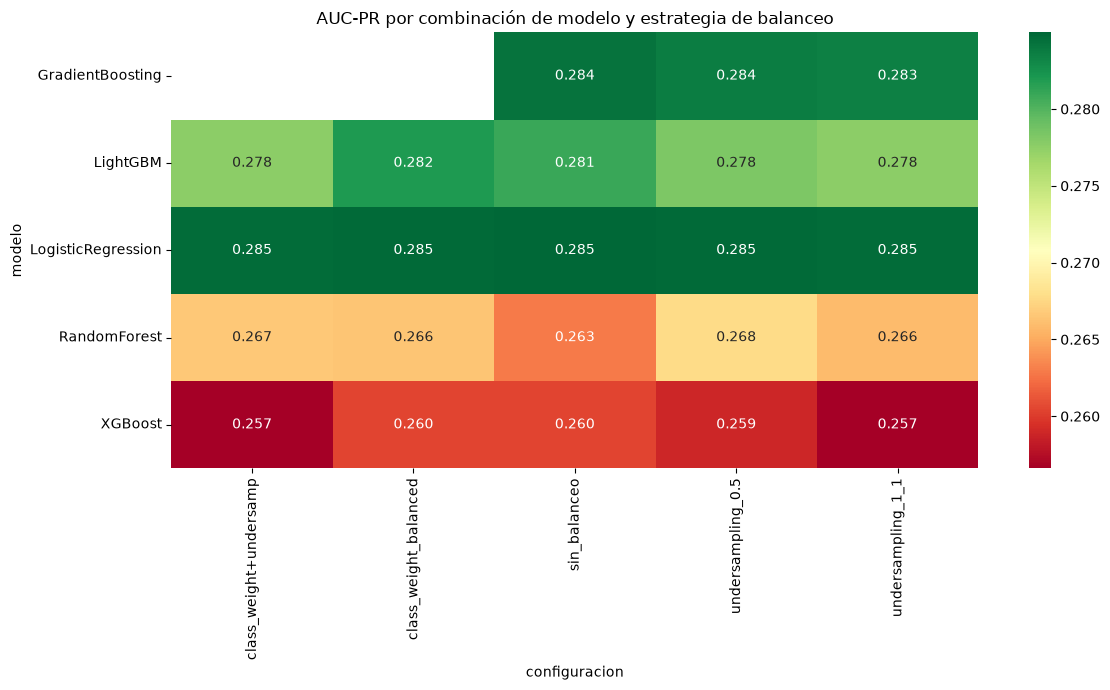

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
pivot = resultados_df.pivot(index="modelo", columns="configuracion", values="auc_pr")
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn")
plt.title("AUC-PR por combinación de modelo y estrategia de balanceo")
plt.tight_layout()
plt.show()

In [9]:
# Submuestreo estratificado para afinamiento de hiperparámetros
# Se usa 40% del train (480k filas) para acelerar RandomizedSearchCV manteniendo representatividad
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=1, train_size=0.4, random_state=42)
for sample_idx, _ in sss.split(X_train, y_train):
    X_train_tuning = X_train.iloc[sample_idx]
    y_train_tuning = y_train.iloc[sample_idx]

print(f"Train completo: {X_train.shape}, {y_train.mean():.4f} positivos")
print(f"Train para tuning (40%): {X_train_tuning.shape}, {y_train_tuning.mean():.4f} positivos")

Train completo: (1200000, 45), 0.1729 positivos
Train para tuning (40%): (480000, 45), 0.1729 positivos


## 5. Afinamiento de Hiperparámetros — Mejor Candidato

Se toma la mejor combinación del screening (configuración × modelo) y se afina con `RandomizedSearchCV` sobre una **muestra estratificada del 40% del conjunto de entrenamiento** (~480k filas, manteniendo el desbalance 82.71%/17.29%).

**Justificación de la estrategia de submuestreo:**
- **Reducción de tiempo**: Con 1.2M filas, cada iteración de CV toma demasiado tiempo (~1 hora por modelo).
- **Representatividad**: 480k filas siguen siendo un dataset robusto y representativo para ajustar hiperparámetros.
- **Estratificación**: `StratifiedShuffleSplit` garantiza que la muestra preserve la proporción de clases original.
- **Enfoque en el mejor**: Afinar solo el candidato #1 del screening (en lugar de los 3 mejores) reduce tiempo sin perder calidad, dado que los 3 mejores mostraron scores muy similares en el screening.

In [10]:
from sklearn.model_selection import RandomizedSearchCV

param_grids = {
    "LogisticRegression": {
        "clf__C": np.logspace(-3, 2, 20),
        "clf__l1_ratio": [0, 0.3, 0.5, 0.7, 1.0],
        #"clf__penalty": ["elasticnet"],
        "clf__solver": ["saga"],
    },
    "RandomForest": {
        "clf__n_estimators": [100, 200, 300],
        "clf__max_depth": [None, 10, 20, 30],
        "clf__min_samples_leaf": [1, 5, 10],
    },
    "XGBoost": {
        "clf__n_estimators": [100, 200, 300],
        "clf__max_depth": [3, 5, 7, 10],
        "clf__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "clf__scale_pos_weight": [1, (y_train==0).sum()/(y_train==1).sum()],
    },
    "LightGBM": {
        "clf__n_estimators": [100, 200, 300],
        "clf__num_leaves": [15, 31, 63],
        "clf__learning_rate": [0.01, 0.05, 0.1],
    },
    "GradientBoosting": {
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [3, 5, 7],
        "clf__learning_rate": [0.01, 0.05, 0.1],
    },
}

In [11]:
from sklearn.model_selection import StratifiedShuffleSplit

# Submuestreo estratificado del train completo (40%)
sss = StratifiedShuffleSplit(n_splits=1, train_size=0.4, random_state=42)
for sample_idx, _ in sss.split(X_train, y_train):
    X_train_tuning = X_train.iloc[sample_idx]
    y_train_tuning = y_train.iloc[sample_idx]

print(f"Train para tuning: {X_train_tuning.shape}, {y_train_tuning.mean():.4f} positivos")

Train para tuning: (480000, 45), 0.1729 positivos


In [12]:
# Cambio 1: Solo top 1 (en lugar de top_3)
top_1 = resultados_df.head(1)  
print(top_1[["configuracion", "modelo", "auc_pr"]])

mejores_modelos_afinados = {}

# Cambio 2: Usar X_train_tuning y y_train_tuning
for _, fila in top_1.iterrows():  
    nombre_config, nombre_modelo = fila["configuracion"], fila["modelo"]
    print(f"\nAfinando: {nombre_config} + {nombre_modelo}")

    usar_cw = 'class_weight' in nombre_config
    modelo_base = construir_modelos(usar_cw)[nombre_modelo]

    if "undersampling" in nombre_config:
        proporcion = 1.0 if "1_1" in nombre_config else 0.5
        pipe = ImbPipeline([
            ("preprocess", preprocessor),
            ("undersample", RandomUnderSampler(sampling_strategy=proporcion, random_state=42)),
            ("clf", modelo_base)
        ])
    else:
        pipe = Pipeline([("preprocess", preprocessor), ("clf", modelo_base)])

    search = RandomizedSearchCV(
        pipe, param_distributions=param_grids[nombre_modelo],
        n_iter=10, cv=2, scoring="average_precision", n_jobs=-1, random_state=42
    )
    # Cambio 3: Usar submuestras en lugar de train completo
    search.fit(X_train_tuning, y_train_tuning)  # <-- CAMBIO AQUÍ

    mejores_modelos_afinados[f"{nombre_config}_{nombre_modelo}"] = search
    print(f"Mejor AUC-PR (CV): {search.best_score_:.4f}")
    print(f"Mejores parámetros: {search.best_params_}")

  configuracion              modelo    auc_pr
0  sin_balanceo  LogisticRegression  0.284991

Afinando: sin_balanceo + LogisticRegression
Mejor AUC-PR (CV): 0.2864
Mejores parámetros: {'clf__solver': 'saga', 'clf__l1_ratio': 0.5, 'clf__C': np.float64(0.011288378916846888)}


TOP 20 FEATURES MÁS IMPORTANTES (por magnitud absoluta)

Mejores parámetros: {'clf__solver': 'saga', 'clf__l1_ratio': 0.5, 'clf__C': np.float64(0.011288378916846888)}
Score CV (AUC-PR): 0.2864

                                    feature  coeficiente  abs_coeficiente
                           comorbilidad_erc     0.338143         0.338143
               complicacion_diabetes_previa     0.293899         0.293899
                              urgencias_12m     0.153211         0.153211
                     riesgo_cv_10_anios_pct     0.074877         0.074877
                           grupo_edad_60_74    -0.022383         0.022383
                     departamento_Atlántico    -0.019983         0.019983
                  nivel_socioeconomico_Bajo     0.017705         0.017705
                    anios_desde_dx_diabetes     0.015845         0.015845
              regimen_afiliacion_Subsidiado    -0.015423         0.015423
                        departamento_Nariño     0.015403         0

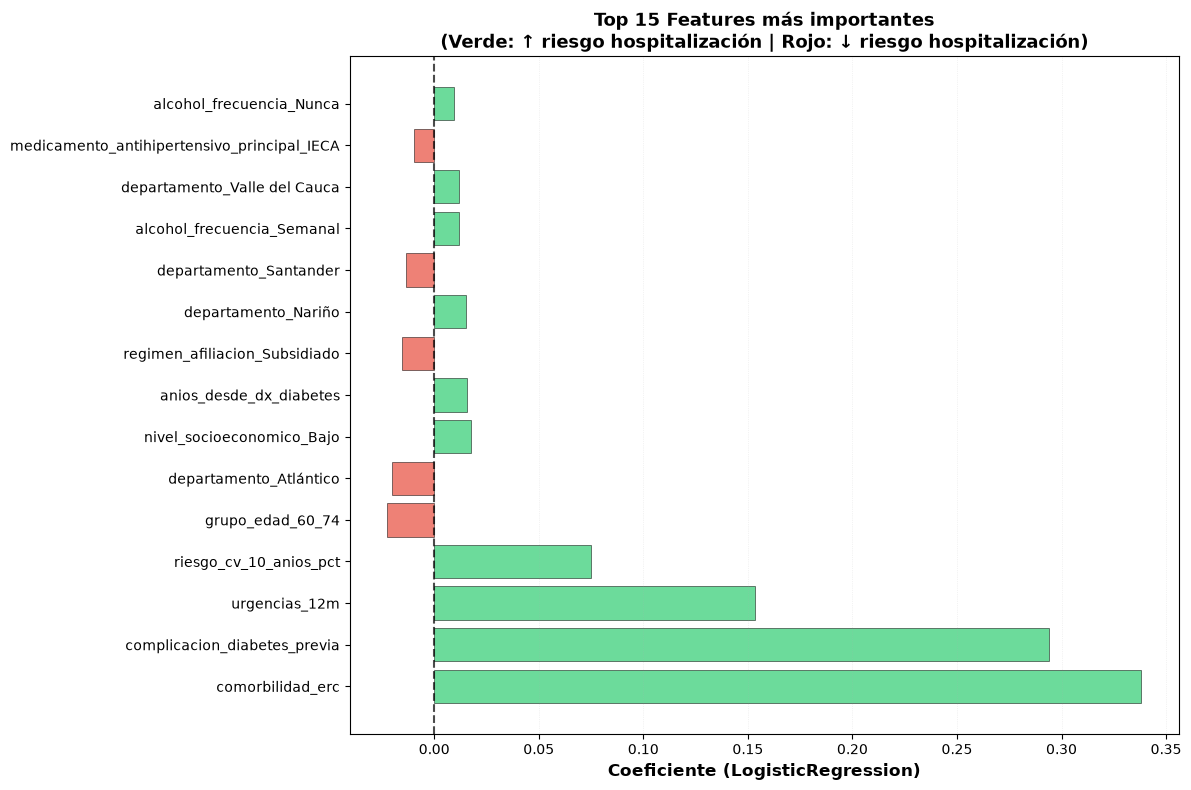


ANÁLISIS DE REGULARIZACIÓN
Tipo de regularización: ElasticNet (50% L1 + 50% L2) - Balance óptimo
C = 0.0113 (regularización fuerte)

Impacto de la regularización:
  • Features con coef ≈ 0 (eliminadas): 37 de 83
  • Features con coef > 0.01 (relevantes): 13
  • Features con coef > 0.05 (muy relevantes): 4

Estadísticas de coeficientes:
  • Máximo (abs): 0.3381
  • Promedio (abs): 0.0144
  • Mediana (abs): 0.0032
  • Total de features: 83


In [13]:
# Análisis de coeficientes del mejor modelo
import matplotlib.pyplot as plt
import pandas as pd

# Extraer el mejor modelo del RandomizedSearchCV
mejor_modelo = list(mejores_modelos_afinados.values())[0]
modelo_pipeline = mejor_modelo.best_estimator_

# Obtener el clasificador (última etapa del pipeline)
clf = modelo_pipeline.named_steps['clf']

# Obtener nombres de features después del preprocesamiento
preprocessor_fitted = modelo_pipeline.named_steps['preprocess']
feature_names = []

# Features numéricas (primer transformer: StandardScaler)
num_features = list(preprocessor_fitted.transformers_[0][2])
feature_names.extend(num_features)

# Features categóricas (segundo transformer: OneHotEncoder)
# preprocessor_fitted.transformers_[1] = ('cat', OneHotEncoder(), categorical_cols)
onehot_encoder = preprocessor_fitted.transformers_[1][1]  # El OneHotEncoder directamente
cat_features_original = list(preprocessor_fitted.transformers_[1][2])

# Obtener nombres después de OneHotEncoding
try:
    # get_feature_names_out devuelve nombres como 'departamento_Antioquia', 'sexo_F', etc.
    cat_features_encoded = onehot_encoder.get_feature_names_out(cat_features_original)
    feature_names.extend(cat_features_encoded)
except (AttributeError, Exception) as e:
    print(f"⚠️ Advertencia: No se pudieron obtener nombres encoded ({e})")
    print(f"Usando nombres categóricos originales...")
    feature_names.extend(cat_features_original)

# Coeficientes
coeficientes = clf.coef_[0]

# Verificar que coincidan dimensiones
if len(feature_names) != len(coeficientes):
    print(f"⚠️ Error de dimensiones: {len(feature_names)} nombres vs {len(coeficientes)} coeficientes")
    print(f"Generando nombres genéricos...")
    feature_names = [f"feature_{i}" for i in range(len(coeficientes))]

# Crear DataFrame con coeficientes
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coeficiente': coeficientes,
    'abs_coeficiente': np.abs(coeficientes)
}).sort_values('abs_coeficiente', ascending=False)

# Mostrar top 20 coeficientes más importantes
print("=" * 95)
print("TOP 20 FEATURES MÁS IMPORTANTES (por magnitud absoluta)")
print("=" * 95)
print(f"\nMejores parámetros: {mejor_modelo.best_params_}")
print(f"Score CV (AUC-PR): {mejor_modelo.best_score_:.4f}\n")
print(coef_df.head(20).to_string(index=False))

# Visualización de top 15 coeficientes
plt.figure(figsize=(12, 8))
top_15 = coef_df.head(15).copy()
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in top_15['coeficiente']]
plt.barh(range(len(top_15)), top_15['coeficiente'], color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
plt.yticks(range(len(top_15)), top_15['feature'], fontsize=10)
plt.xlabel('Coeficiente (LogisticRegression)', fontsize=12, fontweight='bold')
plt.title('Top 15 Features más importantes\n(Verde: ↑ riesgo hospitalización | Rojo: ↓ riesgo hospitalización)', 
          fontsize=13, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
plt.grid(axis='x', alpha=0.3, linestyle=':', linewidth=0.5)
plt.tight_layout()
plt.show()

# Resumen de regularización
print("\n" + "=" * 95)
print("ANÁLISIS DE REGULARIZACIÓN")
print("=" * 95)
l1_ratio = mejor_modelo.best_params_.get('clf__l1_ratio', 0.0)
if l1_ratio == 0.0:
    tipo_reg = "Ridge (L2) - Reduce pero NO elimina coeficientes"
elif l1_ratio == 1.0:
    tipo_reg = "Lasso (L1) - Elimina features poco importantes (coef=0)"
else:
    tipo_reg = f"ElasticNet ({l1_ratio*100:.0f}% L1 + {(1-l1_ratio)*100:.0f}% L2) - Balance óptimo"
    
print(f"Tipo de regularización: {tipo_reg}")
print(f"C = {mejor_modelo.best_params_['clf__C']:.4f} (regularización {'fuerte' if mejor_modelo.best_params_['clf__C'] < 1 else 'débil'})")
print(f"\nImpacto de la regularización:")
print(f"  • Features con coef ≈ 0 (eliminadas): {sum(np.abs(coeficientes) < 0.001)} de {len(coeficientes)}")
print(f"  • Features con coef > 0.01 (relevantes): {sum(np.abs(coeficientes) > 0.01)}")
print(f"  • Features con coef > 0.05 (muy relevantes): {sum(np.abs(coeficientes) > 0.05)}")

# Mostrar estadísticas de coeficientes
print(f"\nEstadísticas de coeficientes:")
print(f"  • Máximo (abs): {np.max(np.abs(coeficientes)):.4f}")
print(f"  • Promedio (abs): {np.mean(np.abs(coeficientes)):.4f}")
print(f"  • Mediana (abs): {np.median(np.abs(coeficientes)):.4f}")
print(f"  • Total de features: {len(coeficientes)}")

## 6. Evaluación Final sobre Test

Evaluación del modelo finalista afinado sobre el **conjunto de prueba completo** (300k filas, nunca antes usado), con métricas alineadas al KPI de negocio de la Pregunta SMART (precisión ≥80% en el 10-20% de pacientes priorizados).

**Nota importante**: Aunque el modelo se afinó usando una muestra del 40% del train, la evaluación final se realiza sobre el **test set completo** (20% del dataset original) para obtener una estimación no sesgada del desempeño en producción.

In [14]:
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix

# Evaluación sobre test set completo (300k filas)
# Nota: mejores_modelos_afinados contiene solo 1 modelo (el mejor del screening)
resultados_finales = []

for nombre, search in mejores_modelos_afinados.items():
    modelo = search.best_estimator_
    y_proba = modelo.predict_proba(X_test)[:, 1]

    # Métrica de negocio: precisión en el top 15% de pacientes priorizados
    top_k = int(len(y_test) * 0.15)
    idx_top = np.argsort(y_proba)[::-1][:top_k]
    precision_top_k = y_test.iloc[idx_top].mean()

    resultados_finales.append({
        "candidato": nombre,
        "auc_roc_test": roc_auc_score(y_test, y_proba),
        "auc_pr_test": average_precision_score(y_test, y_proba),
        "precision_top15pct": precision_top_k,
    })

resultados_finales_df = pd.DataFrame(resultados_finales).sort_values("precision_top15pct", ascending=False)
print("\nResultados en Test Set:")
print(resultados_finales_df.to_string(index=False))


Resultados en Test Set:
                      candidato  auc_roc_test  auc_pr_test  precision_top15pct
sin_balanceo_LogisticRegression      0.671172     0.290425            0.320578


## 7. Modelo Final Seleccionado

In [15]:
mejor_candidato_nombre = resultados_finales_df.iloc[0]["candidato"]
mejor_modelo_final = mejores_modelos_afinados[mejor_candidato_nombre].best_estimator_

print(f"MODELO SELECCIONADO: {mejor_candidato_nombre}\n")
print(classification_report(y_test, mejor_modelo_final.predict(X_test)))
print(confusion_matrix(y_test, mejor_modelo_final.predict(X_test)))

MODELO SELECCIONADO: sin_balanceo_LogisticRegression

              precision    recall  f1-score   support

           0       0.83      1.00      0.91    248130
           1       0.49      0.00      0.01     51870

    accuracy                           0.83    300000
   macro avg       0.66      0.50      0.46    300000
weighted avg       0.77      0.83      0.75    300000

[[247980    150]
 [ 51727    143]]


## 8. Serialización para Despliegue

Se guarda el `Pipeline` completo (preprocesamiento + modelo afinado) en formato `.pkl`. En producción, solo se carga este archivo y se llama `.predict_proba()` sobre datos crudos (sin preprocesamiento manual).

También se exportan los resultados del screening y la comparación final en formato CSV para trazabilidad y documentación.

In [16]:
import joblib
import os

os.makedirs("../app/model", exist_ok=True)
joblib.dump(mejor_modelo_final, "../app/model/modelo_riesgo_hospitalizacion_v1.pkl")

# Exportar resultados para trazabilidad y documentación
resultados_df.to_csv("screening_completo.csv", index=False)
resultados_finales_df.to_csv("evaluacion_test_final.csv", index=False)

print("✅ Modelo guardado en: app/model/modelo_riesgo_hospitalizacion_v1.pkl")
print("✅ Resultados exportados: screening_completo.csv, evaluacion_test_final.csv")

✅ Modelo guardado en: app/model/modelo_riesgo_hospitalizacion_v1.pkl
✅ Resultados exportados: screening_completo.csv, evaluacion_test_final.csv


## 9. Conclusión — Resultado frente al KPI de negocio

**Ajustes metodológicos realizados:** para hacer viable el tiempo de cómputo, se redujo el afinamiento de hiperparámetros a un solo candidato (el mejor del screening, Logistic Regression sin balanceo de clases) y se ejecutó `RandomizedSearchCV` sobre una muestra estratificada del 40% del conjunto de entrenamiento (~480K filas) en vez del 1.2M completo — decisión razonable dado que, en el screening completo (25 combinaciones evaluadas), Logistic Regression superó consistentemente a los modelos de árboles (RandomForest, XGBoost, LightGBM, GradientBoosting) en las cinco estrategias de balanceo probadas, con diferencias mínimas entre sus propias variantes.

**Resultado frente al KPI definido en el EDA (Pregunta SMART, meta ≥80% de precisión en el 10-20% de pacientes priorizados):** el modelo final obtuvo **32.06% de precisión en el top 15%** de pacientes con mayor riesgo predicho — muy por debajo de la meta establecida. El `classification_report` con el umbral de decisión por defecto (0.5) es aún más severo (recall≈0% para la clase positiva), pero no es la métrica relevante para este caso de uso: el objetivo de negocio no es clasificar con un umbral fijo, sino **priorizar y ordenar** a los pacientes de mayor riesgo, por lo que la precisión en el top-k es la métrica correcta de evaluación.

**Este resultado es consistente con las limitaciones ya identificadas en el EDA** (sección 8.3): ninguna variable individual mostró correlación fuerte con la hospitalización, y el propio análisis exploratorio anticipó que alcanzar 80% de precisión requeriría señal predictiva más fuerte de la disponible en el dataset actual. **El MVP, en su estado actual, no cumple el KPI original** — se documenta como limitación honesta del primer ciclo de modelado, y se proponen como siguientes pasos: (1) enriquecer el conjunto de variables con fuentes adicionales (ej. historial longitudinal más allá de 12 meses, variables de interacción no incluidas en el EDA original), (2) revisar si el umbral de 80% de precisión es realista para este problema o si debe recalibrarse con el equipo de negocio dado el techo de desempeño observado, y (3) explorar variables derivadas o términos de interacción, dado que el análisis bivariado ya sugería que ninguna variable aislada explica bien el desenlace.